In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage.io import imread
from skimage.color import rgb2gray
from skimage.filters import gaussian, prewitt_h, prewitt_v, threshold_otsu
from skimage.morphology import dilation, erosion, disk, square
from skimage.filters import median
from scipy.ndimage import binary_fill_holes


In [2]:
from google.colab import files

uploaded = files.upload()

imagens = []

for nome_arquivo in uploaded.keys():
    img = imread(nome_arquivo)

    if len(img.shape) == 3:
        img = rgb2gray(img)

    imagens.append(img)

print(f"{len(imagens)} imagens carregadas")


Saving sandalia2_3.jpg to sandalia2_3.jpg
Saving sandalia2_1.jpg to sandalia2_1.jpg
Saving sandalia2_2.jpg to sandalia2_2.jpg
Saving sandalia1_3.jpg to sandalia1_3.jpg
Saving sandalia1_2.jpg to sandalia1_2.jpg
Saving sandalia1_1.jpg to sandalia1_1.jpg
Saving tenis2_3.jpg to tenis2_3.jpg
Saving tenis2_2.jpg to tenis2_2.jpg
Saving tenis2_1.jpg to tenis2_1.jpg
Saving tenis1_3.jpg to tenis1_3.jpg
Saving tenis1_2.jpg to tenis1_2.jpg
Saving tenis1_1.jpg to tenis1_1.jpg
12 imagens carregadas


(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

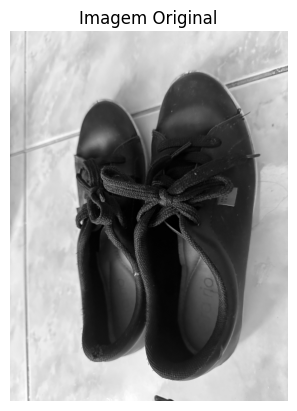

In [3]:
img = imagens[7]

plt.imshow(img, cmap='gray')
plt.title("Imagem Original")
plt.axis('off')


In [4]:
# Destacar o Objeto (Segmentação)
# Filtragem linear + não linear
img_f = gaussian(img, sigma=1)
img_f = median(img_f, square(3))

/tmp/ipython-input-1304540090.py:4: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  img_f = median(img_f, square(3))


(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

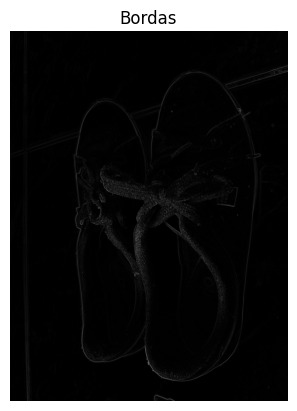

In [5]:
# Detecção de bordas
gx = prewitt_h(img_f)
gy = prewitt_v(img_f)

edges = np.sqrt(gx**2 + gy**2)

plt.imshow(edges, cmap='gray')
plt.title("Bordas")
plt.axis('off')

(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

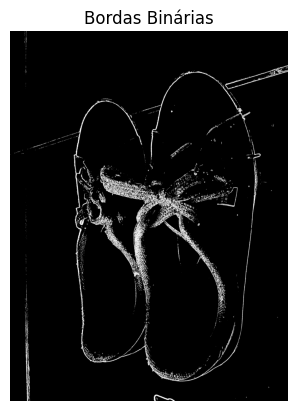

In [6]:
# Binarização
th = threshold_otsu(edges)
edges_bin = edges > th

plt.imshow(edges_bin, cmap='gray')
plt.title("Bordas Binárias")
plt.axis('off')

(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

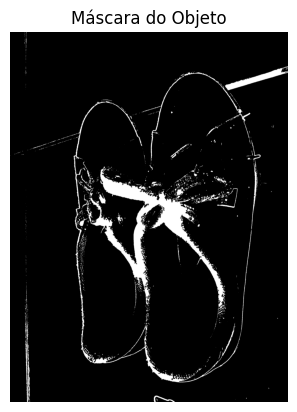

In [7]:
# Morfologia para fechar objeto
mask = dilation(edges_bin, disk(2))
mask = erosion(mask, disk(2))
mask = binary_fill_holes(mask)

plt.imshow(mask, cmap='gray')
plt.title("Máscara do Objeto")
plt.axis('off')

In [8]:
# Área por Contagem de Pixels
# Área em pixels²
area_pixels = np.sum(mask)

print("Área do objeto (pixels²):", area_pixels)

Área do objeto (pixels²): 678851


In [9]:
# Aproximação Geométrica
# Bounding Box
coords = np.argwhere(mask)

y_min, x_min = coords.min(axis=0)
y_max, x_max = coords.max(axis=0)

altura = y_max - y_min
largura = x_max - x_min

area_bbox = altura * largura

print("Área Bounding Box:", area_bbox)

Área Bounding Box: 12181682


(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

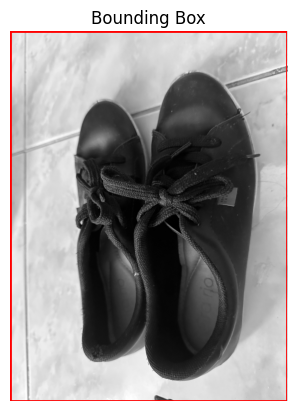

In [10]:
# Visual Bounding Box
plt.imshow(img, cmap='gray')
plt.gca().add_patch(
    plt.Rectangle((x_min, y_min), largura, altura,
                  edgecolor='red', fill=False, linewidth=2)
)
plt.title("Bounding Box")
plt.axis('off')

In [11]:
# Aproximação Circular
# Área equivalente circular
raio_equiv = np.sqrt(area_pixels / np.pi)
area_circulo = np.pi * raio_equiv**2

print("Raio equivalente:", raio_equiv)
print("Área círculo equivalente:", area_circulo)

Raio equivalente: 464.84942136755694
Área círculo equivalente: 678851.0


In [12]:
print("Área real (pixels):", area_pixels)
print("Bounding Box:", area_bbox)
print("Círculo equivalente:", area_circulo)


Área real (pixels): 678851
Bounding Box: 12181682
Círculo equivalente: 678851.0
